### **Post Lab Task**: Perform K-fold and Grid Search on Titanic Dataset.



1. BASELINE K-FOLD CROSS-VALIDATION
  Fold 1 Accuracy: 0.9649
  Fold 2 Accuracy: 0.9386
  Fold 3 Accuracy: 0.9123
  Fold 4 Accuracy: 0.9474
  Fold 5 Accuracy: 0.9204

Mean Baseline Accuracy: 0.9367 (± 0.0189)

2. GRID SEARCH TUNING
Tuned Best Model Fold Scores:
  Fold 1 Accuracy: 0.9737
  Fold 2 Accuracy: 0.9561
  Fold 3 Accuracy: 0.9298
  Fold 4 Accuracy: 0.9474
  Fold 5 Accuracy: 0.9381

Best Cross-Validation Accuracy: 0.9490

Best Parameters Found:
  max_depth: 7
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 80

--- Out-of-Fold Classification Report ---
              precision    recall  f1-score   support

   Malignant       0.95      0.92      0.93       212
      Benign       0.95      0.97      0.96       357

    accuracy                           0.95       569
   macro avg       0.95      0.94      0.95       569
weighted avg       0.95      0.95      0.95       569



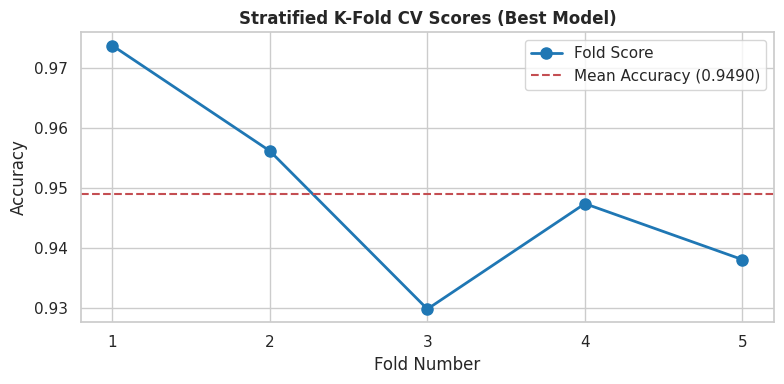

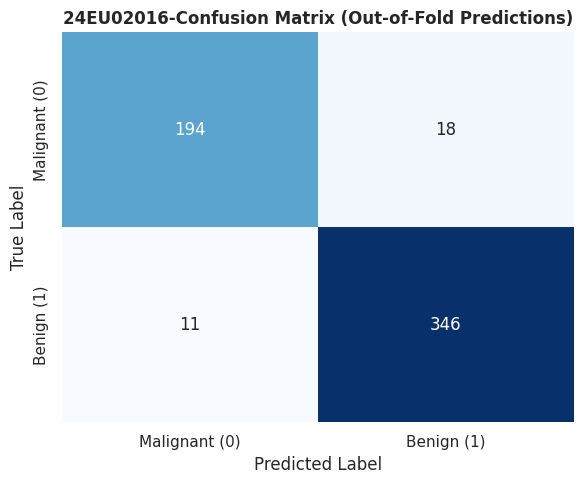

/tmp/ipykernel_784/770764365.py:299: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


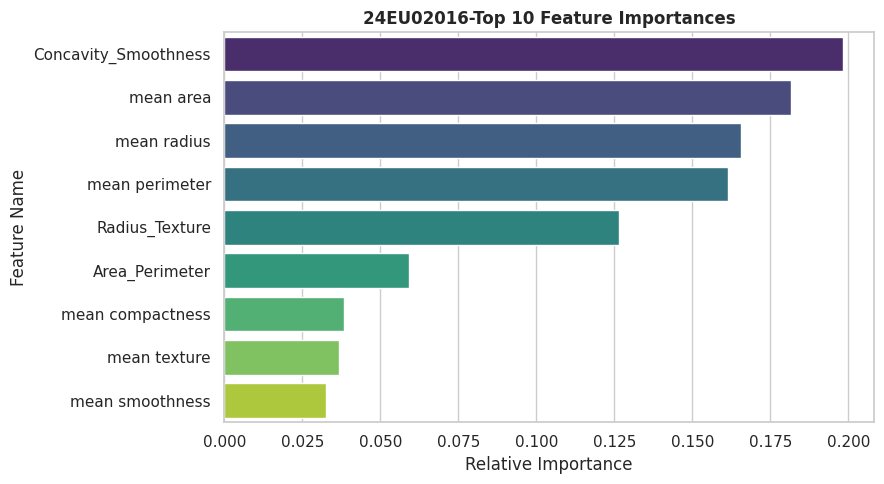

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Set visual style for plots
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOAD DATA & FEATURE ENGINEERING
# ==========================================

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target

# Rename target values
df["Diagnosis"] = df["Target"].map({
    0: "Malignant",
    1: "Benign"
})

# Create additional features
df["Radius_Texture"] = df["mean radius"] * df["mean texture"]
df["Area_Perimeter"] = df["mean area"] / (df["mean perimeter"] + 1)
df["Concavity_Smoothness"] = (
    df["mean concavity"] * df["mean smoothness"]
)

# Feature Selection
num_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
    "Radius_Texture",
    "Area_Perimeter",
    "Concavity_Smoothness"
]

X = df[num_features]
y = df["Target"]

# ==========================================
# 2. PREPROCESSING PIPELINE
# ==========================================

num_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocessor = num_transformer

# Set up Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=25
)

clf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=25
            )
        )
    ]
)

# ==========================================
# 3. BASELINE K-FOLD CROSS-VALIDATION
# ==========================================

print("==========================================")
print("1. BASELINE K-FOLD CROSS-VALIDATION")
print("==========================================")

baseline_scores = cross_val_score(
    clf_pipeline,
    X,
    y,
    cv=skf,
    scoring="accuracy"
)

for fold_idx, score in enumerate(baseline_scores, 1):
    print(
        f"  Fold {fold_idx} Accuracy: {score:.4f}"
    )

print(
    f"\nMean Baseline Accuracy: "
    f"{baseline_scores.mean():.4f} "
    f"(± {baseline_scores.std():.4f})"
)

# ==========================================
# 4. GRID SEARCH HYPERPARAMETER TUNING
# ==========================================

print("\n==========================================")
print("2. GRID SEARCH TUNING")
print("==========================================")

param_grid = {
    "classifier__n_estimators": [80, 150],
    "classifier__max_depth": [3, 5, 7],
    "classifier__min_samples_split": [2, 4],
    "classifier__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=clf_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X, y)

best_model = grid_search.best_estimator_

# Retrieve individual fold scores
best_model_fold_scores = [
    grid_search.cv_results_[f"split{i}_test_score"][
        grid_search.best_index_
    ]
    for i in range(5)
]

print("Tuned Best Model Fold Scores:")

for fold_idx, score in enumerate(
    best_model_fold_scores, 1
):
    print(
        f"  Fold {fold_idx} Accuracy: {score:.4f}"
    )

print(
    f"\nBest Cross-Validation Accuracy: "
    f"{grid_search.best_score_:.4f}"
)

print("\nBest Parameters Found:")

for param, val in grid_search.best_params_.items():
    print(
        f"  {param.split('__')[1]}: {val}"
    )

# Out-of-fold predictions
y_pred = cross_val_predict(
    best_model,
    X,
    y,
    cv=skf
)

print("\n--- Out-of-Fold Classification Report ---")

print(
    classification_report(
        y,
        y_pred,
        target_names=["Malignant", "Benign"]
    )
)

# ==========================================
# 5. VISUALIZATIONS
# ==========================================

# Figure 1: Stratified K-Fold Accuracy Scores

plt.figure(figsize=(8, 4))

plt.plot(
    range(1, 6),
    best_model_fold_scores,
    marker="o",
    linewidth=2,
    markersize=8,
    color="#1f77b4",
    label="Fold Score"
)

plt.axhline(
    y=np.mean(best_model_fold_scores),
    color="r",
    linestyle="--",
    label=(
        f"Mean Accuracy "
        f"({np.mean(best_model_fold_scores):.4f})"
    )
)

plt.title(
    "Stratified K-Fold CV Scores (Best Model)",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# Figure 2: Confusion Matrix
# ==========================================

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Malignant (0)",
        "Benign (1)"
    ],
    yticklabels=[
        "Malignant (0)",
        "Benign (1)"
    ]
)

plt.title(
    "24EU02016-Confusion Matrix (Out-of-Fold Predictions)",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# ==========================================
# Figure 3: Top Feature Importances
# ==========================================

feature_names = num_features

importances = (
    best_model
    .named_steps["classifier"]
    .feature_importances_
)

feat_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": importances
    }
)

feat_df = (
    feat_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=feat_df,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title(
    "24EU02016-Top 10 Feature Importances",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Relative Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()